In [1]:
import sys
python_path = "/data/agapi_workspace/gnn-learning-engine-ar-explain"
if python_path not in sys.path:
    sys.path.insert(0, python_path)
print("Current Python Executable: ", sys.executable)
print("Current sys.path: ", sys.path)

import src
print("Imported src module from: ", src.__file__)

# Set the python path
import os
python_path = "/data/agapi_workspace/gnn-learning-engine-ar-explain/src"
env = os.environ.copy()
env["PYTHONPATH"] = python_path
print("PYTHONPATH set to:", env["PYTHONPATH"])

Current Python Executable:  /home/ubuntu/anaconda3/envs/pyg_env_ar_explain/bin/python
Current sys.path:  ['/data/agapi_workspace/gnn-learning-engine-ar-explain', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python311.zip', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/lib-dynload', '', '/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages', '__editable__.gnn_rai-0.1.finder.__path_hook__']
Imported src module from:  /data/agapi_workspace/gnn-learning-engine-ar-explain/src/__init__.py
PYTHONPATH set to: /data/agapi_workspace/gnn-learning-engine-ar-explain/src


# Clinical Trials Interventions

In [2]:
import os
import random
import numpy as np
import pandas as pd

# Engine imports
from src.utils.utils import fix_all_seeds, timer

# Fix all seeds for reproducibility
fix_all_seeds(seed=42)

### Take a look at the available data for the Clinical Trials dataset

In [3]:
dataset_name = 'rel-trial'
task_name = 'study-outcome'

# dataset db files
studies_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/studies.parquet')
designs_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/designs.parquet')
facilities_studies_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/facilities_studies.parquet')
facilities_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/facilities.parquet')
sponsors_studies_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/sponsors_studies.parquet')

# task files
train_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/{task_name}/train.parquet')
val_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/{task_name}/val.parquet')
test_df = pd.read_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/{task_name}/test.parquet')
outcome_df = pd.concat([train_df, val_df, test_df], ignore_index=True)[['nct_id', 'outcome']]
outcome_with_dates_df = pd.concat([train_df, val_df, test_df], ignore_index=True)

# collect prediction entity ids per split
nct_ids_all = studies_df['nct_id'].tolist()
nct_ids_train = train_df['nct_id'].tolist()
nct_ids_val = val_df['nct_id'].tolist()
nct_ids_test = test_df['nct_id'].tolist()
nct_ids_all_from_task = outcome_df['nct_id'].tolist()

# how many per split, how many unique per split, overlap?
print(f'All data: {len(nct_ids_all)} examples, {len(set(nct_ids_all))} unique examples, {len(nct_ids_all_from_task)} from task files, {len(set(nct_ids_all_from_task))} unique from task files')
print(f'Train split: {len(nct_ids_train)} examples, {len(set(nct_ids_train))} unique examples')
print(f'Val split: {len(nct_ids_val)} examples, {len(set(nct_ids_val))} unique examples')
print(f'Test split: {len(nct_ids_test)} examples, {len(set(nct_ids_test))} unique examples')
overlap_train_val = set(nct_ids_train).intersection(set(nct_ids_val))
overlap_train_test = set(nct_ids_train).intersection(set(nct_ids_test))
overlap_val_test = set(nct_ids_val).intersection(set(nct_ids_test))
print(f'Overlap train-val: {len(overlap_train_val)} examples')
print(f'Overlap train-test: {len(overlap_train_test)} examples')
print(f'Overlap val-test: {len(overlap_val_test)} examples')

# assuming that the overlap is zero across splits, collect all pairs of (nct_id, outcome) in outcome_df
assert len(overlap_train_val) == 0, "Train and Val splits have overlapping nct_ids!"
assert len(overlap_train_test) == 0, "Train and Test splits have overlapping nct_ids!"
assert len(overlap_val_test) == 0, "Val and Test splits have overlapping nct_ids!"

All data: 273160 examples, 273160 unique examples, 13779 from task files, 13779 unique from task files
Train split: 11994 examples, 11994 unique examples
Val split: 960 examples, 960 unique examples
Test split: 825 examples, 825 unique examples
Overlap train-val: 0 examples
Overlap train-test: 0 examples
Overlap val-test: 0 examples


In [4]:
GENERATE_DATA = False

### Intervention 1: Add a join path that introduces data leakage

Specifically, add a table of preliminary evaluation were the evaluation is correlated with the outcome
* `preliminary_evaluation(reviewer_id, nct_id, rating)`, where every study is associated with `3` intermediate reviews and the rating is correlated with the outcome of the study. 

In [5]:
if GENERATE_DATA:
    # For each study in the outcome_df, add 5 intermediate reviews with ratings correlated to the outcome
    preliminary_evaluation = []
    rev_id_counter = 0
    n_reviews_per_study = 3
    for idx, row in outcome_df.iterrows():
        nct_id = row['nct_id']
        outcome = row['outcome']
        for _ in range(n_reviews_per_study):
            rev_id = rev_id_counter
            # Correlate grade with outcome: if outcome is positive (1), rating is more likely to be high (4 or 5)
            if outcome == 1:
                rating = random.choices([1, 2, 3, 4, 5], weights=[1, 1, 1, 3, 4])[0]
            else:
                rating = random.choices([1, 2, 3, 4, 5], weights=[4, 3, 1, 1, 1])[0]
            preliminary_evaluation.append({'reviewer_id': rev_id, 'nct_id': nct_id, 'rating': rating})
            rev_id_counter += 1
    # Save the new intermediate reviews table
    intermediate_reviews_df = pd.DataFrame(preliminary_evaluation)
    intermediate_reviews_df.to_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/preliminary_evaluation_w_column_level_data_leakage.parquet', index=False)

### Intervention 2: Add a join path that introduces data leakage only for some of the cases

Now, add a table of preliminary evaluation were the evaluation is correlated with the outcome only for certain types of evaluation. Otherwise, it is independent of the outcome.
* `preliminary_evaluation(reviewer_id, nct_id, eval_category, rating)`, where every study is associated with `3` intermediate reviews per `eval_category`.
* we use `10` values `eval_category` (A, B, C, D, F, ...) which represent evaluation themes, e.g., `ethics`, `methodology`, `financial`, etc. 
* lowest rating is correlated with the outcome of the study only for evaluation themes: (A, B, C) 

In [6]:
if GENERATE_DATA:
    # For each study in the outcome_df, add 5 intermediate reviews with ratings correlated to the outcome
    preliminary_evaluation = []
    rev_id_counter = 0
    n_reviews_per_study_per_category = 1
    for idx, row in outcome_df.iterrows():
        nct_id = row['nct_id']
        outcome = row['outcome']
        for eval_category in ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J']:
            for _ in range(n_reviews_per_study):
                rev_id = rev_id_counter
                # Correlate grade with outcome only for eval_category A, B, C
                if eval_category in ['A', 'B', 'C']:
                    if outcome == 1:
                        rating = random.choices([1, 2, 3, 4, 5], weights=[1, 1, 1, 3, 4])[0]
                    else:
                        rating = random.choices([1, 2, 3, 4, 5], weights=[4, 3, 1, 1, 1])[0]
                # Independent rating for other categories
                else:
                    rating = random.randint(1, 5)
                preliminary_evaluation.append({'reviewer_id': rev_id, 'nct_id': nct_id, 'eval_category': eval_category, 'rating': rating})
                rev_id_counter += 1

    # Save the new intermediate reviews table
    intermediate_reviews_df = pd.DataFrame(preliminary_evaluation)
    intermediate_reviews_df.to_parquet(f'/workspace/benchmark_datasets/{dataset_name}/db/preliminary_evaluation_w_tuple_level_data_leakage.parquet', index=False)

### New Task: replace the study-outcome with a new task that is purely based on counting neighbors

Assign `outcome = 1` if the study `>1` sponsor and `outcome = 0` if it has `=1` sponsor.

In [7]:
if GENERATE_DATA:
    # Create a new task where the outcome is based on the number of sponsors for each study
    sponsor_counts = sponsors_studies_df.groupby('nct_id').size().reset_index(name='sponsor_count')
    sponsor_based_outcome_df = outcome_with_dates_df.copy()
    # replace outcome based on sponsor counts
    sponsor_based_outcome_df['outcome'] = sponsor_based_outcome_df['nct_id'].map(
        lambda x: 1 if sponsor_counts[sponsor_counts['nct_id'] == x]['sponsor_count'].values[0] > 1 else 0
    )
    # add noise, flip 10% of outcomes
    sponsor_based_outcome_df['outcome'] = sponsor_based_outcome_df.apply(
        lambda row: 1 - row['outcome'] if random.random() < 0.1 else row['outcome'],
        axis=1
    )

    # print distribution of new outcomes
    outcome_distribution = sponsor_based_outcome_df['outcome'].value_counts(normalize=True)
    print(f'New outcome distribution based on sponsor counts:\n{outcome_distribution}')

    # Split into train, val, test based on original splits
    sponsor_based_train_df = sponsor_based_outcome_df[sponsor_based_outcome_df['nct_id'].isin(nct_ids_train)]
    sponsor_based_val_df = sponsor_based_outcome_df[sponsor_based_outcome_df['nct_id'].isin(nct_ids_val)]
    sponsor_based_test_df = sponsor_based_outcome_df[sponsor_based_outcome_df['nct_id'].isin(nct_ids_test)]

    # Save new task files
    os.makedirs(f'/workspace/benchmark_datasets/{dataset_name}/tasks/study-sponsor-count-outcome/', exist_ok=True)
    sponsor_based_train_df.to_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/study-sponsor-count-outcome/train.parquet', index=False)
    sponsor_based_val_df.to_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/study-sponsor-count-outcome/val.parquet', index=False)
    sponsor_based_test_df.to_parquet(f'/workspace/benchmark_datasets/{dataset_name}/tasks/study-sponsor-count-outcome/test.parquet', index=False)

# Clinical Trials Case Study

In [8]:
import os
import copy
import json
from typing import Any, Dict, Optional, Tuple, Union

import numpy as np
import pandas as pd
import torch
import shutil
import torch_frame
from sklearn.metrics import roc_auc_score
from matplotlib import pyplot as plt

# Engine imports
from src.explain.explainer import RDLExplainer
from src.load_utils import load_config, load_dataset_and_task, construct_graph, load_model

# the above imports use safelogger, I want to disable it for this script
# e.g., I get the following 2025-10-17 21:57:59,692 - SafeLogger - INFO - Loading model configuration... bellow
# i don't want that
import logging
logging.getLogger("SafeLogger").disabled = True
logging.getLogger("task_registry").disabled = True
logging.getLogger("gnn_app").disabled = True
logging.getLogger("sentence_transformers.SentenceTransformer").disabled = True
logging.getLogger("torch_frame.utils.io").disabled = True

# Suppress warnings from PyTorch about weights loading
# /workspace/miniconda3/envs/pyg_env/lib/python3.11/site-packages/torch_frame/utils/io.py:113: UserWarning: Weights only load failed. Please file an issue to make `torch.load(weights_only=True)` compatible in your case. Please use `torch.serialization.add_safe_globals([scalar])` to allowlist this global.
#   warnings.warn(f"{warn_msg} Please use "
import warnings
warnings.filterwarnings(
    "ignore",
    message="Weights only load failed. Please file an issue to make `torch.load\\(weights_only=True\\)` compatible.*"
)

/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages/snowflake/snowpark/session.py:36: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


2025-11-22 21:26:22,287 - task_registry - INFO - Registered task type: TaskType.BINARY_CLASSIFICATION
2025-11-22 21:26:22,288 - task_registry - INFO - Registered task type: TaskType.MULTILABEL_CLASSIFICATION
2025-11-22 21:26:22,288 - task_registry - INFO - Registered task type: TaskType.MULTICLASS_CLASSIFICATION
2025-11-22 21:26:22,288 - task_registry - INFO - Registered task type: TaskType.REGRESSION
2025-11-22 21:26:22,289 - task_registry - INFO - Registered task type: TaskType.REPEATED_LINK_PREDICTION
2025-11-22 21:26:22,289 - task_registry - INFO - Registered task type: TaskType.LINK_PREDICTION


In [9]:
explanation_task_type = 'original'

if explanation_task_type == 'original':
    root_dir = './eval_local/results_case_study/data/rel-trial-study-outcome'
elif explanation_task_type == 'intervention_1': # data leakage column level
    root_dir = './eval_local/results_case_study/data/rel-trial-data-leakage-column-study-outcome'
elif explanation_task_type == 'intervention_2': # data leakage tuple level
    root_dir = './eval_local/results_case_study/data/rel-trial-data-leakage-tuple-study-outcome'
elif explanation_task_type == 'counting_sponsors':
    root_dir = './eval_local/results_case_study/data/rel-trial-study-sponsors-count-outcome'

data_config_path = os.path.join(root_dir, 'data_config.yaml')
model_config_path = os.path.join(root_dir, 'model_config.yaml')
model_params_path = os.path.join(root_dir, 'model.pth')

### Load Data and Model

In [10]:
# Load configuration
model_config = load_config(model_config_path)
device = model_config.training_parameters.device
print(f'Using device: {device}')

# Load dataset and task
dataset, task, task_parser = load_dataset_and_task(data_config_path) 
task_type = task.task_type
dataset_name = task.dataset.dataset_name
task_name = task.task_name
print(f'Dataset name: {dataset_name}. Task name: {task_name}. Task type: {task_type}.')

# Construct graph data
data, col_stats_dict = construct_graph(model_config, dataset)

# Load model, from saved state dict
model_to_explain = load_model(model_config, model_params_path, construct=True, from_state_dict=True, data=data, col_stats_dict=col_stats_dict, task=task)

Using device: cuda
Dataset name: rel-trial. Task name: study-outcome. Task type: binary_classification.


### Load Inference Results

In [11]:
# Prepare explanation task, using soft targets
explanation_task = copy.deepcopy(task)
explanation_task.explanation_target_type = 'soft'
explanation_task.explanation_target_column = 'predictions'
explanation_task.explanation_soft_target_column = 'processed_output'
explanation_task.target_col = explanation_task.explanation_soft_target_column if explanation_task.explanation_target_type == 'soft' else explanation_task.explanation_target_column
prediction_col = 'predictions'
ground_truth_col = 'targets'

if explanation_task_type == 'original':
      explanation_table = pd.read_parquet(f'./eval_local/top_1_model_inference/rel-trial/study-outcome/predictions_test.parquet')
elif explanation_task_type == 'intervention_1':
      explanation_table = pd.read_parquet(f'./eval_local/results_case_study/inference/rel-trial-data-leakage-column-study-outcome/predictions_test.parquet')
elif explanation_task_type == 'intervention_2':
      explanation_table = pd.read_parquet(f'./eval_local/results_case_study/inference/rel-trial-data-leakage-tuple-study-outcome/predictions_test.parquet')
elif explanation_task_type == 'counting_sponsors':
      explanation_table = pd.read_parquet(f'./eval_local/results_case_study/inference/rel-trial-study-sponsor-count-outcome/predictions_test.parquet')
else:
      raise ValueError(f'Unknown xai_query_type: {xai_query_type}')
      
explanation_task.train_table.df = explanation_table
explanation_task.val_table.df = explanation_table
explanation_task.test_table.df = explanation_table
print(f'Prepared explanation task with {len(explanation_task.train_table.df)} training samples, '
      f'{len(explanation_task.val_table.df)} validation samples, and {len(explanation_task.test_table.df)} test samples.')

display(explanation_table.head())

from sklearn.metrics import roc_auc_score
roc_auc = roc_auc_score(explanation_table['outcome'], explanation_table['processed_output'])
print(f'ROC-AUC on explanation task data: {roc_auc}')

Prepared explanation task with 825 training samples, 825 validation samples, and 825 test samples.


,timestamp,nct_id,outcome,output,processed_output,predictions,nct_id_mapped
0,2021-01-01,53166,0,-0.545949,0.366805,0,53166
1,2021-01-01,61798,0,-1.105215,0.248764,0,61792
2,2021-01-01,208914,1,1.612793,0.833799,1,208935
3,2021-01-01,209079,1,0.428842,0.605597,1,209101
4,2021-01-01,214210,1,1.848855,0.863993,1,214190


ROC-AUC on explanation task data: 0.7132686789437361


### Initialize Explainer

In [12]:
# Initialize the explainer
explainer = RDLExplainer(model_config, model_to_explain, data, explanation_task)

### Learn Masks

In [13]:
# Learn masks
mask_types = ['column', 'fkpk']
masks_all = {}
metrics_all = {}

for mask_type in mask_types:
    print(f'Learning mask of type: {mask_type}')
    mask_learning_config = {'reg_eps': 0.01, 'learning_rate': 0.05, 'epochs': 50}
    if mask_type == 'column':
        mask_learning_config['explanation_type'] = 'column'
        mask_learning_config['elimination_strategy'] = 'permutation_joint'
    elif mask_type == 'fkpk':
        mask_learning_config['explanation_type'] = 'fkpk'
        mask_learning_config['elimination_strategy'] = 'zero'
    mask, mask_vals, metrics = explainer.learn_masks(
                                            eps = mask_learning_config['reg_eps'],
                                            explanation_type = mask_learning_config['explanation_type'], 
                                            elimination_strategy = mask_learning_config['elimination_strategy'],
                                            n_epochs = mask_learning_config['epochs'],
                                            lr = mask_learning_config['learning_rate'],
                                        )
    masks_all[mask_learning_config['explanation_type']] = mask
    metrics_all[mask_learning_config['explanation_type']] = metrics

Learning mask of type: column
Learning mask of type: fkpk


/home/ubuntu/anaconda3/envs/pyg_env_ar_explain/lib/python3.11/site-packages/torch/_compile.py:32: UserWarning: optimizer contains a parameter group with duplicate parameters; in future, this will cause an error; see github.com/pytorch/pytorch/issues/40967 for more information
  return disable_fn(*args, **kwargs)


Mask type: column
Mask type: fkpk


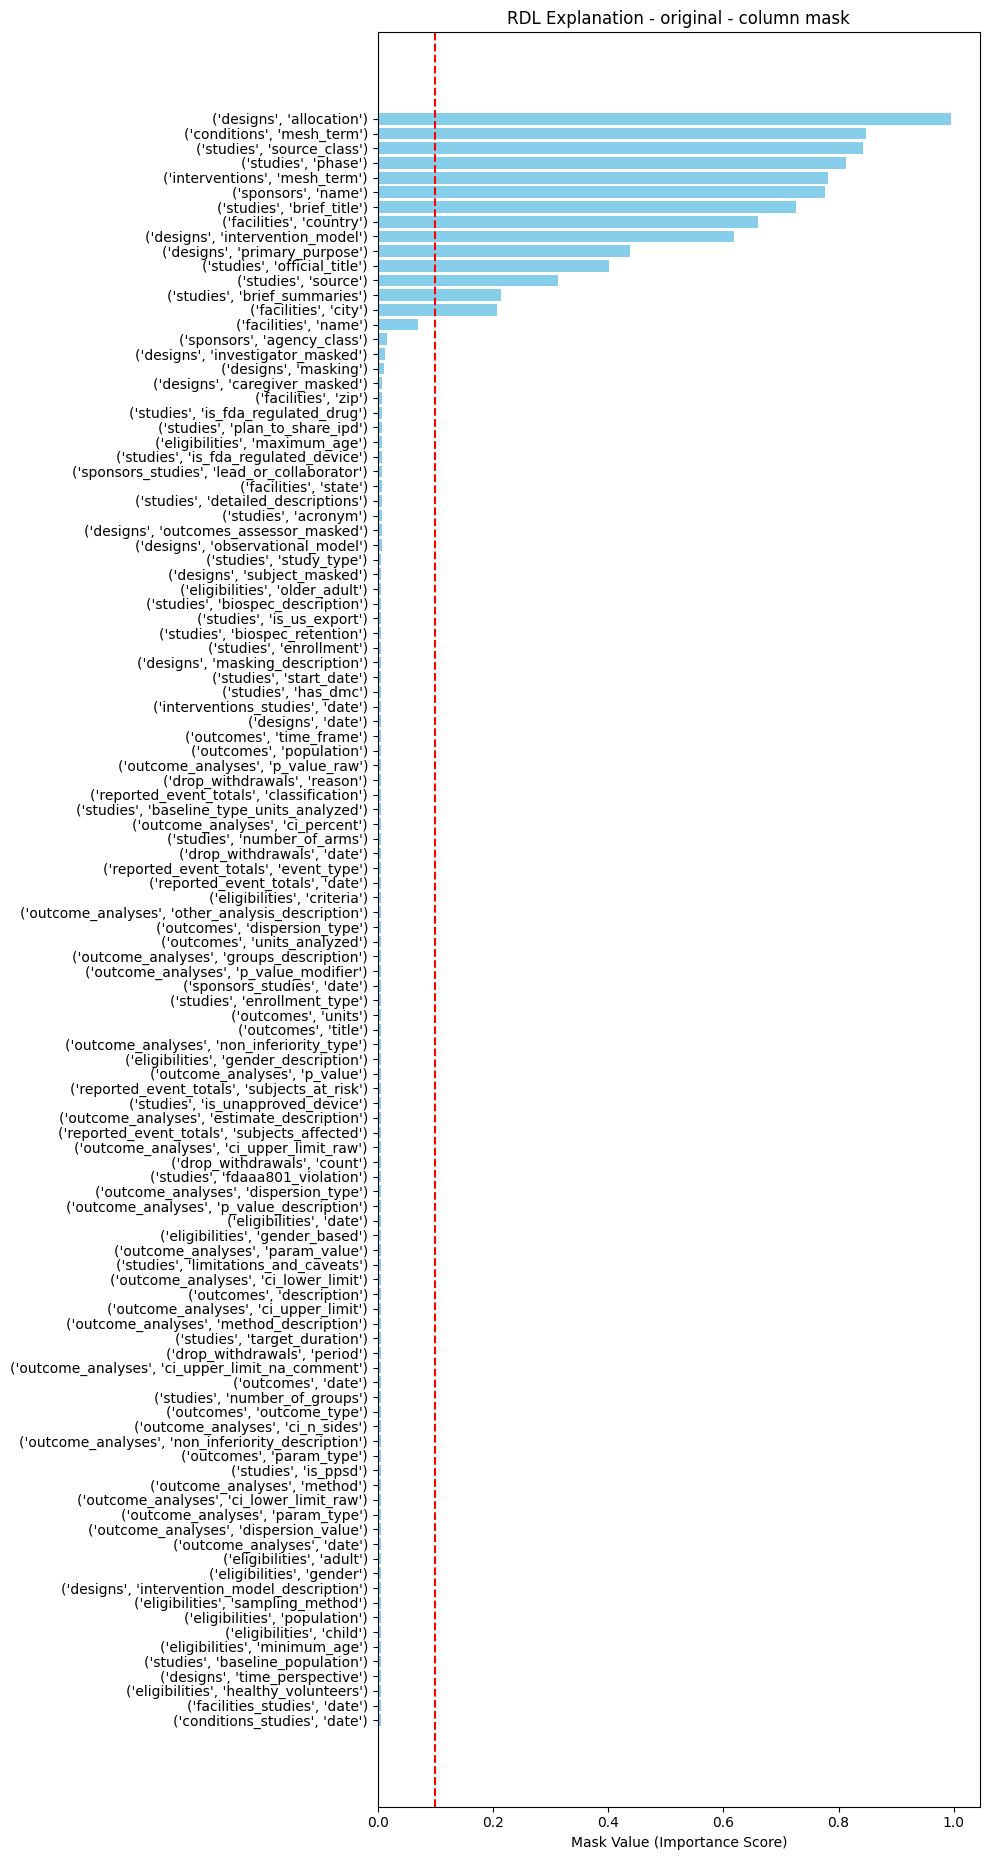

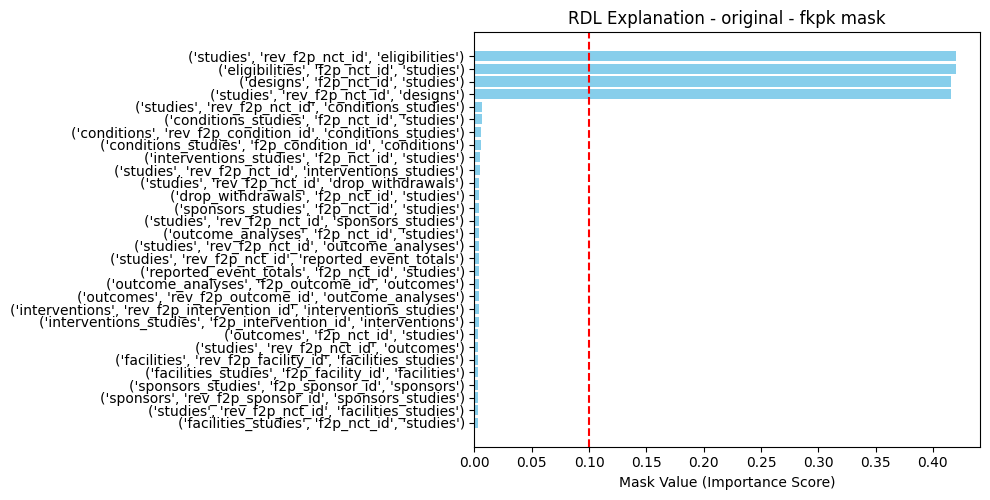

In [14]:
for mask_type in mask_types:
    print(f'Mask type: {mask_type}')
    mask = masks_all[mask_type]
    metrics = metrics_all[mask_type]

    # Prepare data for plotting
    explanation_elements = []
    importance_scores = []
    for explanation_element, mask_value in mask.items():
        explanation_elements.append(f'{explanation_element}')
        importance_scores.append(torch.sigmoid(mask_value).item())  # Apply sigmoid to get importance score between 0 and 1

    # Create a DataFrame for easier plotting
    importance_df = pd.DataFrame({
        'Explanation Element': explanation_elements,
        'Importance Score': importance_scores
    })
    # Sort the DataFrame by importance score
    importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
    # show_top_k = True

    # Plotting
    plt.figure(figsize=(10, 0.17*len(importance_df)))
    plt.barh(importance_df['Explanation Element'], importance_df['Importance Score'], color='skyblue')
    plt.xlabel('Mask Value (Importance Score)')
    plt.title(f'RDL Explanation - {explanation_task_type} - {mask_type} mask')
    plt.gca().invert_yaxis()  # Invert y-axis to have the highest scores on top
    plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
    plt.tight_layout()
    plt.savefig(f'./eval_local/results_case_study/figs/rel-trial/mask_values_{explanation_task_type}_{mask_type}_mask.png', dpi=300, bbox_inches='tight')

Mask type: column
Final task loss during mask learning: 0.6221342248289199


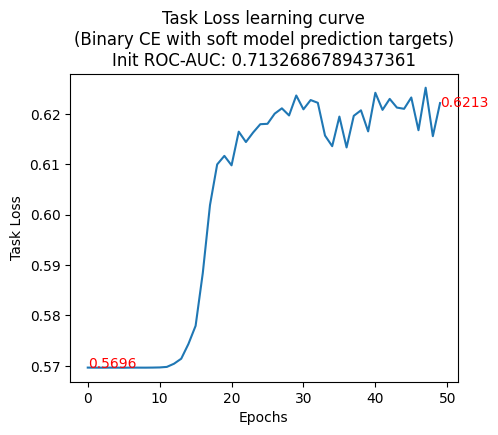

Mask type: fkpk
Final task loss during mask learning: 0.633994468554909


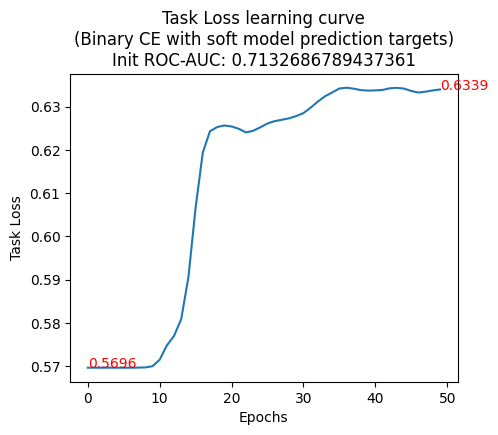

In [15]:
for mask_type in mask_types:
    print(f'Mask type: {mask_type}')
    mask = masks_all[mask_type]
    metrics = metrics_all[mask_type]

    # show the task_loss curve from metrics
    print(f"Final task loss during mask learning: {metrics['task_loss'][-1]}")
    plt.figure(figsize=(5, 4))
    plt.plot(metrics['task_loss'], label='Task Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Task Loss')
    plt.title(f'Task Loss learning curve\n(Binary CE with soft model prediction targets)\nInit ROC-AUC: {roc_auc}')
    # add the first and the average of last ten numbers as text annotations on the curve with red color
    plt.text(0, metrics['task_loss'][0], f'{metrics["task_loss"][0]:.4f}', color='red')
    plt.text(len(metrics['task_loss'])-1, np.mean(metrics['task_loss'][-10:]), f'{np.mean(metrics["task_loss"][-10:]):.4f}', color='red')
    # plt.savefig(f'./eval_local/results_case_study/figs/rel-trial/mask_learning_task_loss_curve_{explanation_task_type}_{mask_type}.png', dpi=300, bbox_inches='tight')
    plt.show()

In [16]:
def map_category_label_to_category_value(data, table_name, col_name, table_df):
    # get the column index for the table and column name
    node_to_col_names_dict={node_type: data[node_type].tf.col_names_dict for node_type in data.node_types}
    try:
        column_index = node_to_col_names_dict[table_name][torch_frame.categorical].index(col_name)
    except ValueError:
        raise ValueError(f"Column {col_name} is not a categorical column in table {table_name}")

    # get the category label for the table and column
    category_label = data[table_name].tf.feat_dict[torch_frame.categorical][:, column_index].cpu().numpy()
    
    # get the original category values from the dataframe
    category_value = table_df[col_name].values

    # map category label to category value
    category_label_to_value = {}
    for label, value in zip(category_label, category_value):
        if label in category_label_to_value:
            assert category_label_to_value[label] == value, f"Category label {label} already mapped to {category_label_to_value[label]}, but got {value}"
        else:
            category_label_to_value[label] = value

    return category_label_to_value

Generated 14 candidate filters.
Filter 1: ('designs', 'allocation', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2])
Filter 4: ('studies', 'phase', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2, 3, 4, 5, 6, 7, 8])
Filter 9: ('designs', 'intervention_model', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2, 3, 4, 5])
Learning filter mask on 3 candidate filters:
Filter 1: ('designs', 'allocation', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2])
Learned filter mask: [{'mask_vals': tensor([-0.3426, -5.1803, -5.0767])}, {'mask_vals': tensor([-0.7175, -4.9237,  0.3484, -4.8767,  0.9680, -4.5154, -4.8609, -4.8444,
        -5.0422])}, {'mask_vals': tensor([ 0.0341, -5.1170, -5.0817, -4.9380, -5.0562, -5.0042])}]
Mapping of category labels to category values: {1: 'None', 0: 'Randomized', 2: 'Non-Randomized'}


/tmp/ipykernel_2459537/2506802271.py:70: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Filter 2: ('studies', 'phase', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2, 3, 4, 5, 6, 7, 8])
Learned filter mask: [{'mask_vals': tensor([ 0.3438, -5.1926, -5.0890])}, {'mask_vals': tensor([-0.6056, -4.9633,  0.6413, -4.8812,  0.9900, -4.4958, -4.8323, -4.8866,
        -5.0398])}, {'mask_vals': tensor([-0.5233, -5.0488, -5.0876, -4.6657, -4.9475, -4.9300])}]
Mapping of category labels to category values: {1: 'None', 0: 'Randomized', 2: 'Non-Randomized'}
Filter 3: ('designs', 'intervention_model', <stype.categorical: 'categorical'>, 'equality', [0, 1, 2, 3, 4, 5])
Learned filter mask: [{'mask_vals': tensor([-2.1971, -5.2775, -4.8996])}, {'mask_vals': tensor([-0.4726, -4.9219,  0.2867, -4.8549,  0.9811, -4.5103, -4.8532, -4.9050,
        -5.0448])}, {'mask_vals': tensor([ 2.5051, -4.9351, -5.0527, -5.1086, -5.0489, -5.0541])}]
Mapping of category labels to category values: {1: 'None', 0: 'Randomized', 2: 'Non-Randomized'}


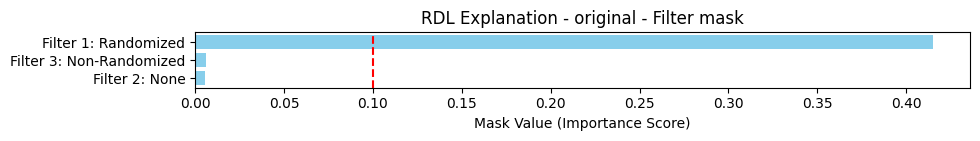

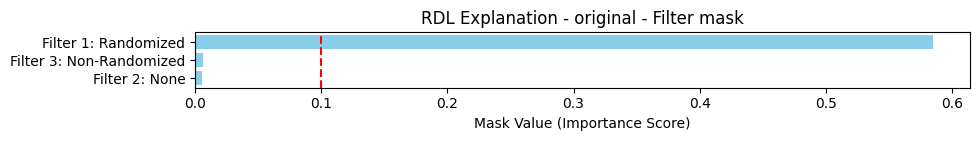

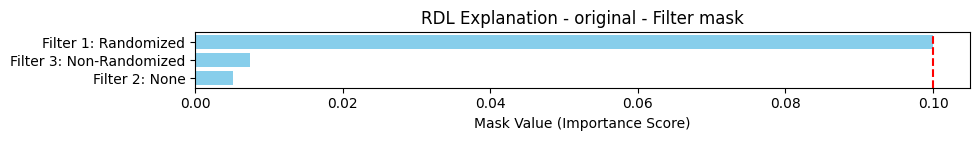

In [21]:
from learn_filter_masks import collect_candidate_filters_given_important_columns

# use all columns in the important columns for filter generation 
# get important columns from column mask, sort first by mask value descending
mask_column = masks_all['column']
mask_column_sorted = dict(sorted(mask_column.items(), key=lambda item: item[1], reverse=True))
important_columns = [explanation_element for explanation_element, mask_value in mask_column_sorted.items() if torch.sigmoid(mask_value).item() >= 0.1]
all_columns = [explanation_element for explanation_element, _ in mask_column_sorted.items()]

candidate_filters, value_mapping = collect_candidate_filters_given_important_columns(data, col_stats_dict, important_columns)

print(f'Generated {len(candidate_filters)} candidate filters.')
# enumerate filter predicates
for i, filter_pred in enumerate(candidate_filters):
    if filter_pred[3]=='dummy':
        continue
    print(f'Filter {i+1}: {filter_pred}')

if explanation_task_type == 'intervention_2':
    # pick top-2 important column and learn filter mask only on that column
    candidate_filters = [candidate_filters[0]]  #, candidate_filters[1]]
elif explanation_task_type == 'original':
    # use all candidate filters that are not 'dummy'
    candidate_filters = [filter_pred for filter_pred in candidate_filters if filter_pred[3]!='dummy']

if candidate_filters:
    print(f'Learning filter mask on {len(candidate_filters)} candidate filters:')
    for i, filter_pred in enumerate(candidate_filters):
        print(f'Filter {i+1}: {filter_pred}')
        filter_mask_learning_config = {'reg_eps': 0.01, 'learning_rate': 0.05, 'epochs': 50}
        filter_mask, mask_vals, metrics = explainer.learn_masks(
                                                eps = filter_mask_learning_config['reg_eps'],
                                                explanation_type = 'filter', 
                                                elimination_strategy = 'permutation_independent',
                                                n_epochs = filter_mask_learning_config['epochs'],
                                                lr = filter_mask_learning_config['learning_rate'],
                                                filter_predicates = candidate_filters,
                                            )
        print(f'Learned filter mask: {filter_mask}')
        # Prepare data for plotting
        filter_pred = candidate_filters[0]
        if filter_pred[2] == torch_frame.categorical:
            table_name = filter_pred[0]
            col_name = filter_pred[1]
            table_df = dataset.db.table_dict[table_name].df
            category_mapping = map_category_label_to_category_value(data, table_name, col_name, table_df)
            print("Mapping of category labels to category values:", category_mapping)
        else:
            category_mapping = None
        explanation_elements = []
        importance_scores = []
        for i, mask_value in enumerate(filter_mask[0]['mask_vals']):
            label = category_mapping[candidate_filters[0][4][i]] if category_mapping else candidate_filters[0][4][i]
            explanation_elements.append(f'Filter {i+1}: {label}')
            importance_scores.append(torch.sigmoid(mask_value).item())
        # Create a DataFrame for easier plotting
        importance_df = pd.DataFrame({
            'Explanation Element': explanation_elements,
            'Importance Score': importance_scores
        })
        # Sort the DataFrame by importance score
        importance_df = importance_df.sort_values(by='Importance Score', ascending=False)
        # Plotting
        plt.figure(figsize=(10, 0.24*len(importance_df)))
        plt.barh(importance_df['Explanation Element'], importance_df['Importance Score'], color='skyblue')
        plt.xlabel('Mask Value (Importance Score)')
        plt.title(f'RDL Explanation - {explanation_task_type} - Filter mask')
        plt.gca().invert_yaxis()
        plt.axvline(x=0.1, color='red', linestyle='--', label='Threshold (0.1)')
        plt.tight_layout()
        plt.savefig(f'./eval_local/results_case_study/figs/rel-trial/filter_{i+1}_mask_values_{explanation_task_type}_filter_mask.png', dpi=300, bbox_inches='tight')

In [ ]:
import torch_frame

def map_category_label_to_category_value(data, table_name, col_name, table_df):
    # get the column index for the table and column name
    node_to_col_names_dict={node_type: data[node_type].tf.col_names_dict for node_type in data.node_types}
    try:
        column_index = node_to_col_names_dict[table_name][torch_frame.categorical].index(col_name)
    except ValueError:
        raise ValueError(f"Column {col_name} is not a categorical column in table {table_name}")

    # get the category label for the table and column
    category_label = data[table_name].tf.feat_dict[torch_frame.categorical][:, column_index].cpu().numpy()
    
    # get the original category values from the dataframe
    category_value = table_df[col_name].values

    # map category label to category value
    category_label_to_value = {}
    for label, value in zip(category_label, category_value):
        if label in category_label_to_value:
            assert category_label_to_value[label] == value, f"Category label {label} already mapped to {category_label_to_value[label]}, but got {value}"
        else:
            category_label_to_value[label] = value

    return category_label_to_value

# sort the design df by nct_id to match the data order 
designs_df = dataset.db.table_dict['designs'].df
map_category_label_to_category_value(data, 'designs', 'allocation', designs_df) 